# Filtering data in 1D

In [1]:
# %load_ext autoreload
# %autoreload 2

import cmocean
import numpy as np
import pandas as pd
import verde as vd

import airbornegeo

/home/mdtanker/airbornegeo/.pixi/envs/default/lib/python3.14/site-packages/xrft/xrft.py:326: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  daft = \mathbb{F}(da - \overline{da})
/home/mdtanker/airbornegeo/.pixi/envs/default/lib/python3.14/site-packages/xrft/xrft.py:497: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  da = \mathbb{F}(daft - \overline{daft})
/home/mdtanker/airbornegeo/.pixi/envs/default/lib/python3.14/site-packages/xrft/xrft.py:692: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  da' = da - \overline{da}
/home/mdtanker/airbornegeo/.pixi/envs/default/lib/python3.14/site-packages/xrft/xrft.py:767: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not wor

In [2]:
data_df = pd.read_csv("data/AGAP_gravity_survey_processed.csv")
data_df = data_df[
    [
        "easting",
        "northing",
        "line",
        "unixtime",
        "grav_disturbance",
        "distance_along_line",
        "height",
    ]
]
data_df = data_df.sort_values(["line", "unixtime"]).reset_index(drop=True)
data_df.head()

,easting,northing,line,unixtime,grav_disturbance,distance_along_line,height
0,1.000024e+06,226237.330771,1,1.229507e+09,1186.4,0.000000,4156.1
1,1.000083e+06,226246.631269,1,1.229507e+09,342.1,59.842447,4156.0
2,1.000142e+06,226255.809132,1,1.229507e+09,-1965.9,119.693401,4156.1
3,1.000201e+06,226264.969079,1,1.229507e+09,820.0,179.545645,4156.4
4,1.000260e+06,226274.156809,1,1.229507e+09,3198.0,239.285174,4156.6


## Filter a line

In [3]:
# extract a single line from the survey
line_df = data_df[data_df.line == 4]

### Spatial filtering
We can perform 1D filtering based on the distance along the flight line. 

In [4]:
line_df["grav_disturbance_filtered_spatial"] = airbornegeo.filter_line(
    line_df,
    filter_width=19_000,  # 19 km low pass gaussian filter
    filter_type="lowpass",
    filter_shape="gaussian",
    data_column="grav_disturbance",
    filter_by_column="distance_along_line",
    pad_width_percentage=10,
)

Text(0, 0.5, 'mGal')

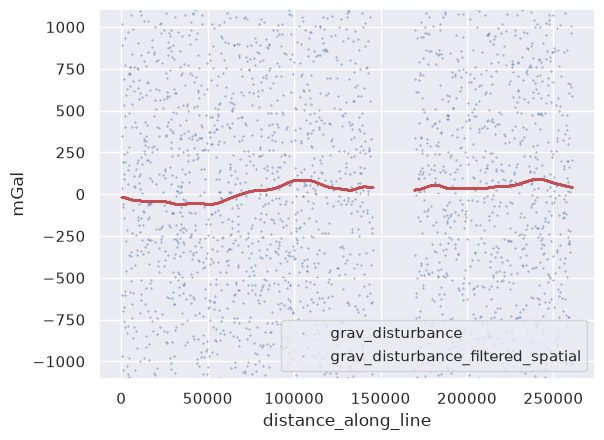

In [5]:
maxabs = vd.maxabs(line_df.grav_disturbance, percentile=60)
ax = line_df.plot.line(
    "distance_along_line",
    "grav_disturbance",
    style="b.",
    ms=0.6,
    ylim=(-maxabs, maxabs),
)
ax = line_df.plot.line(
    "distance_along_line",
    "grav_disturbance_filtered_spatial",
    style="r.",
    ms=0.6,
    ax=ax,
    ylim=(-maxabs, maxabs),
)
ax.set_ylabel("mGal")

### Temporal filtering
We can also perform 1D filtering based on the time. 

In [6]:
line_df = line_df.sort_values("unixtime")

line_df["grav_disturbance_filtered_temporal"] = airbornegeo.filter_line(
    line_df,
    filter_width=400,  # 400 sec low pass gaussian filter
    filter_type="lowpass",
    filter_shape="gaussian",
    data_column="grav_disturbance",
    filter_by_column="unixtime",
    pad_width_percentage=10,
)

Text(0, 0.5, 'mGal')

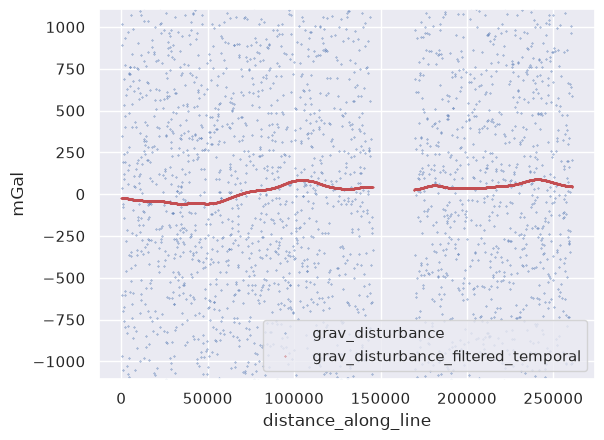

In [7]:
ax = line_df.plot.line(
    "distance_along_line",
    "grav_disturbance",
    style="b.",
    ms=0.6,
    ylim=(-maxabs, maxabs),
)
ax = line_df.plot.line(
    "distance_along_line",
    "grav_disturbance_filtered_temporal",
    style="r.",
    ms=0.6,
    ax=ax,
    ylim=(-maxabs, maxabs),
)
ax.set_ylabel("mGal")

### Filtering with equivalent sources
If our data is gravity or magnetic anomalies, an alternative method is to fit an equivalent source model to the unfiltered data, and either either block-reduction, damping, source-depth, or predicting at a high elevation (upward continuation) to smooth the data.

Text(0, 0.5, 'mGal')

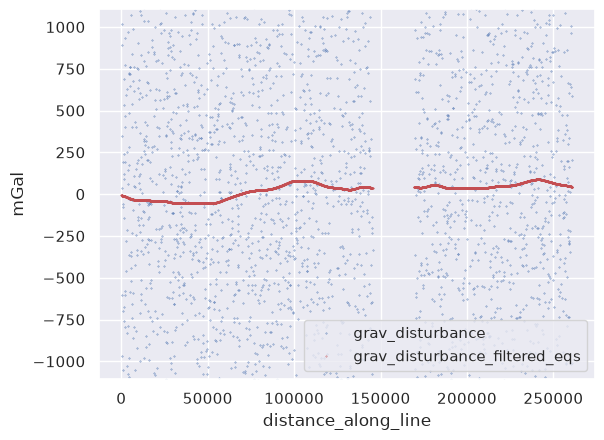

In [8]:
eqs = airbornegeo.eq_sources_1d(
    line_df,
    data_column="grav_disturbance",
    depth="default",
    damping=1e4,
    block_size=500,
)

line_df["grav_disturbance_filtered_eqs"] = eqs.predict(
    (
        line_df.distance_along_line,
        np.zeros_like(line_df.distance_along_line),
        line_df.height,
        # np.full_like(line_df.height, 10e3) # use this if you want to upward continue the data
    )
)

ax = line_df.plot.line(
    "distance_along_line",
    "grav_disturbance",
    style="b.",
    ms=0.6,
    ylim=(-maxabs, maxabs),
)
ax = line_df.plot.line(
    "distance_along_line",
    "grav_disturbance_filtered_eqs",
    style="r.",
    ms=0.6,
    ax=ax,
    ylim=(-maxabs, maxabs),
)
ax.set_ylabel("mGal")

### Compare filtering methods

Text(0, 0.5, 'mGal')

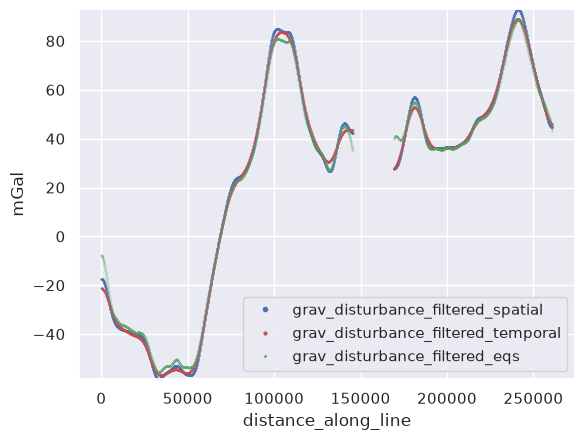

In [9]:
ylim = vd.minmax(
    line_df[
        [
            "grav_disturbance_filtered_spatial",
            "grav_disturbance_filtered_temporal",
            "grav_disturbance_filtered_eqs",
        ]
    ],
)
ax = line_df.plot.line(
    "distance_along_line",
    "grav_disturbance_filtered_spatial",
    style="b.",
    ms=0.6,
    ylim=ylim,
)
ax = line_df.plot.line(
    "distance_along_line",
    "grav_disturbance_filtered_temporal",
    style="r.",
    ms=0.4,
    ax=ax,
    ylim=ylim,
)
ax = line_df.plot.line(
    "distance_along_line",
    "grav_disturbance_filtered_eqs",
    style="g.",
    ms=0.2,
    ax=ax,
    ylim=ylim,
)
ax.legend(markerscale=10)
ax.set_ylabel("mGal")

## Filter all lines in a survey

### Spatial filtering

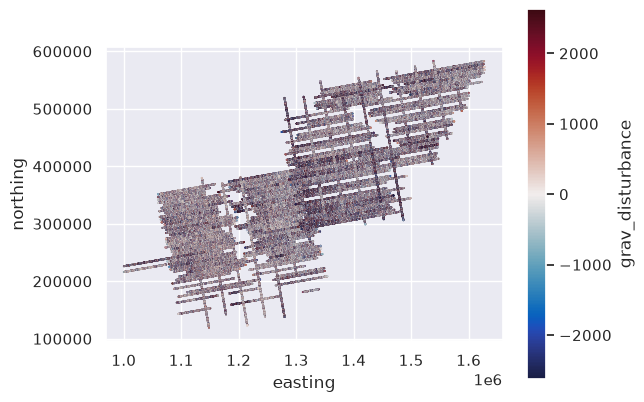

In [10]:
# plot the unfiltered gravity disturbance data
maxabs = vd.maxabs(line_df.grav_disturbance, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="grav_disturbance",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
)
ax.set_aspect("equal")

In [11]:
data_df["grav_disturbance_filtered_spatial"] = airbornegeo.filter_line(
    data_df,
    filter_width=19_000,  # 19 km low pass gaussian filter
    filter_type="lowpass",
    filter_shape="gaussian",
    data_column="grav_disturbance",
    filter_by_column="distance_along_line",
    groupby_column="line",
    pad_width_percentage=10,
)

Segments:   0%|          | 0/100 [00:00<?, ?it/s]

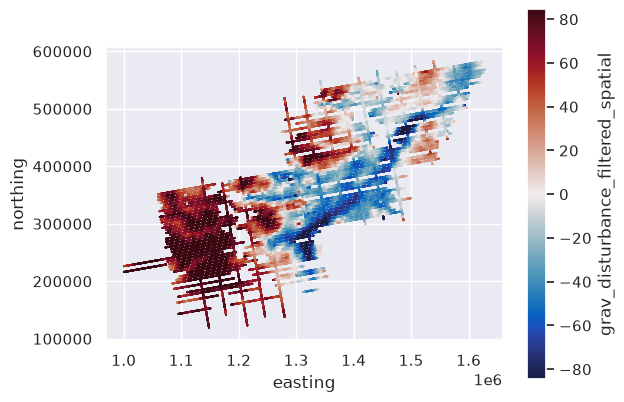

In [12]:
# plot the filtered gravity disturbance data
maxabs = vd.maxabs(line_df.grav_disturbance_filtered_spatial, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="grav_disturbance_filtered_spatial",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
)
ax.set_aspect("equal")

### Temporal filtering

In [13]:
data_df["grav_disturbance_filtered_temporal"] = airbornegeo.filter_line(
    data_df,
    filter_width=500,  # 500 sec low pass gaussian filter
    filter_type="lowpass",
    filter_shape="gaussian",
    data_column="grav_disturbance",
    filter_by_column="unixtime",
    groupby_column="line",
    pad_width_percentage=10,
)

Segments:   0%|          | 0/100 [00:00<?, ?it/s]

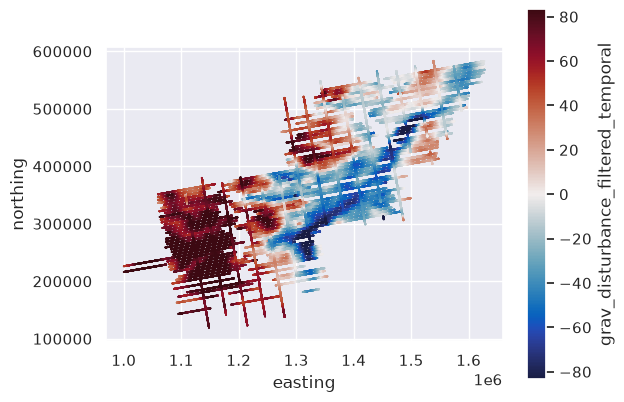

In [14]:
# plot the filtered gravity disturbance data
maxabs = vd.maxabs(line_df.grav_disturbance_filtered_temporal, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="grav_disturbance_filtered_temporal",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
)
ax.set_aspect("equal")

### Equivalent source filtering

In [15]:
eqs = airbornegeo.eq_sources_1d(
    data_df,
    data_column="grav_disturbance",
    depth="default",
    damping=1e4,
    # damping=1e5,
    # damping=1e6,
    block_size=500,
    groupby_column="line",
)

Segments:   0%|          | 0/100 [00:00<?, ?it/s]

In [16]:
pbar = data_df.groupby("line")
for segment_name, segment_data in pbar:
    line_eqs = eqs[segment_name]
    data_df.loc[data_df.line == segment_name, "grav_disturbance_filtered_eqs"] = (
        line_eqs.predict(
            (
                segment_data.distance_along_line,
                np.zeros_like(segment_data.distance_along_line),
                segment_data.height,
            )
        )
    )

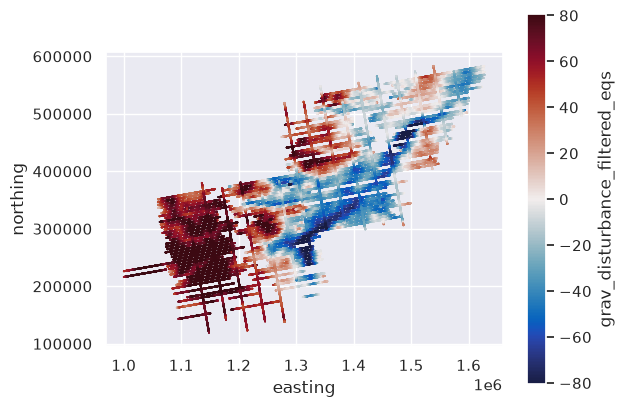

In [17]:
# plot the filtered gravity disturbance data
maxabs = vd.maxabs(line_df.grav_disturbance_filtered_eqs, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="grav_disturbance_filtered_eqs",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
)
ax.set_aspect("equal")